# The real resonance: 2.0443 GHz

Plots the coarse (2-3 GHz, 1 MHz step) and fine (±5 MHz, 20 kHz step) sweep data already collected, showing the confirmed resonance dip. The 2.3 GHz region checked separately turned out to be pure noise (no repeatability between two independent sweeps), so this is the one real feature found so far.

Noise floor reference line is from the earlier RF-off measurement (-64.2 dBm, 1 MHz RBW / 10 dB atten / no averaging) -- taken under a wider analyzer span than the fine sweep here, so the fine sweep's true local noise floor is likely somewhat lower than this line.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

coarse = np.loadtxt("data/resonance_coarse_sweep_2-3GHz_1MHz.csv", delimiter=",", skiprows=1)
fine = np.loadtxt("data/resonance_fine_sweep.csv", delimiter=",", skiprows=1)

coarse_freqs_hz, coarse_power_dbm = coarse[:, 0], coarse[:, 1]
fine_freqs_hz, fine_power_dbm = fine[:, 0], fine[:, 1]

NOISE_FLOOR_DBM = -64.2

resonance_idx = np.argmin(fine_power_dbm)
resonance_freq = fine_freqs_hz[resonance_idx]
resonance_power = fine_power_dbm[resonance_idx]

coarse_baseline = np.median(coarse_power_dbm[coarse_freqs_hz > 2.1e9])
true_depth = coarse_baseline - resonance_power

print(f"resonance frequency: {resonance_freq/1e9:.6f} GHz")
print(f"reflected power at resonance: {resonance_power:.1f} dBm")
print(f"off-resonance baseline (coarse sweep, 2.1-3.0 GHz): {coarse_baseline:.1f} dBm")
print(f"true dip depth: {true_depth:.1f} dB")

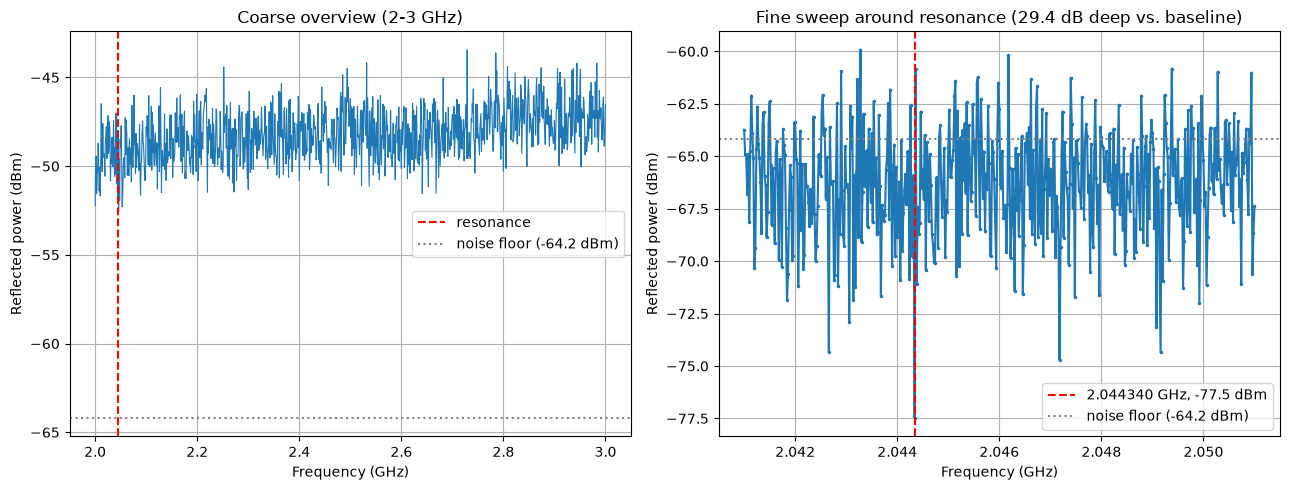

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(coarse_freqs_hz / 1e9, coarse_power_dbm, linewidth=0.8)
ax.axvline(resonance_freq / 1e9, color='r', linestyle='--', label='resonance')
ax.axhline(NOISE_FLOOR_DBM, color='gray', linestyle=':', label='noise floor (-64.2 dBm)')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Coarse overview (2-3 GHz)")
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(fine_freqs_hz / 1e9, fine_power_dbm, marker='.', markersize=3)
ax.axvline(resonance_freq / 1e9, color='r', linestyle='--',
           label=f'{resonance_freq/1e9:.6f} GHz, {resonance_power:.1f} dBm')
ax.axhline(NOISE_FLOOR_DBM, color='gray', linestyle=':', label='noise floor (-64.2 dBm)')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title(f"Fine sweep around resonance ({true_depth:.1f} dB deep vs. baseline)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()